# Customer Lifetime Value (LTV) Prediction Model

**Objective:** Predict the 12-month forward lifetime value of customers from their purchase behavior, to help the marketing team prioritize retention spend and identify high-value customers early.

**Data:** Synthetic e-commerce transaction data (3,000 customers, ~70,000 transactions, 24-month history). Generated to mimic realistic RFM (Recency, Frequency, Monetary) purchase patterns across four latent value tiers.

**Approach:**
1. Split each customer's history into a **feature window** (first 12 months) and a **label window** (following 12 months) — this avoids data leakage since in production you'd only ever have data *before* the prediction date.
2. Engineer RFM + behavioral features from the feature window.
3. Train and compare **Random Forest** and **XGBoost** regressors to predict `future_ltv`.
4. Evaluate using MAE, RMSE, R².
5. Segment all customers into Low / Medium / High / VIP based on predicted LTV.

**Tools:** Python, Pandas, Scikit-learn, XGBoost, Matplotlib, Seaborn


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

## 1. Load Data

Two source tables: `customers.csv` (signup + demographic info) and `transactions.csv` (order-level transaction log).

In [2]:
customers = pd.read_csv("../data/customers.csv", parse_dates=["signup_date"])
transactions = pd.read_csv("../data/transactions.csv", parse_dates=["transaction_date"])

print(f"Customers: {len(customers):,}")
print(f"Transactions: {len(transactions):,}")
customers.head()

Customers: 3,000
Transactions: 69,586


,customer_id,signup_date,acquisition_channel,age,city_tier
0,CUST00001,2023-10-23,Paid Ads,19,Tier 3
1,CUST00002,2023-08-26,Organic Search,47,Tier 3
2,CUST00003,2023-09-10,Email,42,Tier 1
3,CUST00004,2023-07-07,Email,34,Tier 1
4,CUST00005,2023-12-31,Social Media,43,Tier 3


In [3]:
transactions.head()

,transaction_id,customer_id,transaction_date,category,order_value,quantity
0,TXN000001,CUST00001,2024-01-08,Apparel,363.67,3
1,TXN000002,CUST00001,2024-04-18,Books,451.48,3
2,TXN000003,CUST00001,2024-07-26,Home & Kitchen,503.34,1
3,TXN000004,CUST00001,2025-04-05,Apparel,735.23,1
4,TXN000005,CUST00001,2025-04-09,Sports,585.97,4


## 2. Time-Based Train/Label Window Split

To predict *future* LTV without leaking future information into the features, we split each customer's 24-month history into:
- **Feature window** — first 12 months (what we'd know *today*)
- **Label window** — the following 12 months (what we're trying to predict: `future_ltv`)

Only customers who signed up early enough to have a full 24-month history are kept.

In [4]:
FEATURE_WINDOW_MONTHS = 12
CUTOFF_DATE = customers["signup_date"].min() + pd.DateOffset(months=FEATURE_WINDOW_MONTHS)
LABEL_END_DATE = CUTOFF_DATE + pd.DateOffset(months=FEATURE_WINDOW_MONTHS)

eligible_customers = customers[customers["signup_date"] <= CUTOFF_DATE - pd.DateOffset(months=1)].copy()

feature_txns = transactions[
    (transactions["transaction_date"] <= CUTOFF_DATE) &
    (transactions["customer_id"].isin(eligible_customers["customer_id"]))
]
label_txns = transactions[
    (transactions["transaction_date"] > CUTOFF_DATE) &
    (transactions["transaction_date"] <= LABEL_END_DATE) &
    (transactions["customer_id"].isin(eligible_customers["customer_id"]))
]

print(f"Feature window ends: {CUTOFF_DATE.date()}")
print(f"Label window ends:   {LABEL_END_DATE.date()}")
print(f"Eligible customers:  {len(eligible_customers):,}")

Feature window ends: 2024-07-01
Label window ends:   2025-07-01
Eligible customers:  3,000


## 3. Feature Engineering — RFM + Behavioral Features

From the feature window we compute: **Frequency** (order count), **Recency** (days since last purchase), **Monetary/AOV** (average order value), purchase rate, category diversity, and account tenure.

In [5]:
snapshot_date = CUTOFF_DATE

agg = feature_txns.groupby("customer_id").agg(
    frequency=("transaction_id", "count"),
    monetary_total=("order_value", "sum"),
    aov=("order_value", "mean"),
    last_purchase=("transaction_date", "max"),
    first_purchase=("transaction_date", "min"),
    total_quantity=("quantity", "sum"),
    n_categories=("category", "nunique"),
).reset_index()

agg["recency_days"] = (snapshot_date - agg["last_purchase"]).dt.days
agg["tenure_days"] = (snapshot_date - agg["first_purchase"]).dt.days
agg["purchase_rate"] = agg["frequency"] / agg["tenure_days"].replace(0, 1) * 30

features = eligible_customers.merge(agg, on="customer_id", how="left")

for col in ["frequency", "monetary_total", "aov", "total_quantity", "n_categories", "purchase_rate"]:
    features[col] = features[col].fillna(0)
features["recency_days"] = features["recency_days"].fillna(FEATURE_WINDOW_MONTHS * 30)
features["account_age_days"] = (snapshot_date - features["signup_date"]).dt.days

features[["customer_id", "frequency", "monetary_total", "aov", "recency_days", "purchase_rate"]].describe()

,frequency,monetary_total,aov,recency_days,purchase_rate
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,10.935000,17554.900827,1044.281503,45.780667,1.432709
std,10.331974,30713.982631,676.721356,62.888533,1.396422
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2188.642500,579.996429,7.000000,0.593766
50%,8.000000,6875.985000,889.437914,23.000000,1.071429
75%,14.000000,17239.535000,1376.729583,57.000000,1.869849
max,71.000000,233658.040000,3701.280000,360.000000,30.000000


## 4. Build the Label — Actual Future LTV

count      3000.000000
mean      19709.538013
std       35771.171319
min           0.000000
25%        2098.820000
50%        7320.015000
75%       17042.325000
max      234218.260000
Name: future_ltv, dtype: float64


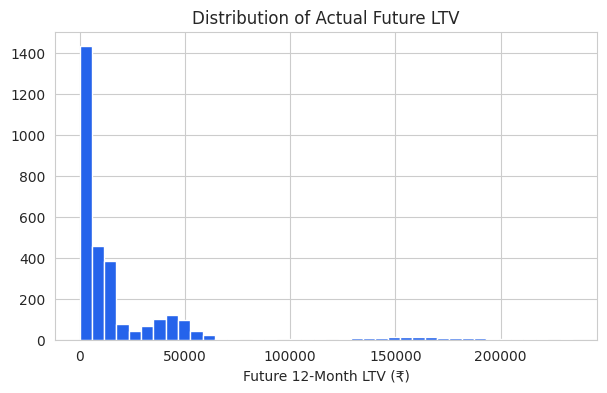

In [6]:
label_agg = label_txns.groupby("customer_id")["order_value"].sum().reset_index()
label_agg.columns = ["customer_id", "future_ltv"]

dataset = features.merge(label_agg, on="customer_id", how="left")
dataset["future_ltv"] = dataset["future_ltv"].fillna(0)

print(dataset["future_ltv"].describe())
dataset["future_ltv"].hist(bins=40, figsize=(7,4), color="#2563EB")
plt.title("Distribution of Actual Future LTV")
plt.xlabel("Future 12-Month LTV (₹)")
plt.show()

## 5. Train / Test Split

In [7]:
feature_cols = [
    "frequency", "monetary_total", "aov", "recency_days", "tenure_days",
    "purchase_rate", "total_quantity", "n_categories", "account_age_days", "age",
]
categorical_cols = ["acquisition_channel", "city_tier"]

X = pd.get_dummies(dataset[feature_cols + categorical_cols], columns=categorical_cols, drop_first=True)
y = dataset["future_ltv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 2400  |  Test: 600


## 6. Train Models — Random Forest vs XGBoost

In [8]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

xgb = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:15s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | R2: {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = [evaluate(y_test, rf_preds, "Random Forest"), evaluate(y_test, xgb_preds, "XGBoost")]
results_df = pd.DataFrame(results)
results_df

Random Forest   | MAE:  6220.32 | RMSE: 13055.85 | R2: 0.8717
XGBoost         | MAE:  6720.75 | RMSE: 13491.47 | R2: 0.8630


,model,MAE,RMSE,R2
0,Random Forest,6220.317180,13055.847731,0.871703
1,XGBoost,6720.750582,13491.472795,0.862998


**Random Forest** achieved the lowest RMSE and highest R² on the held-out test set, so it's selected as the production model.

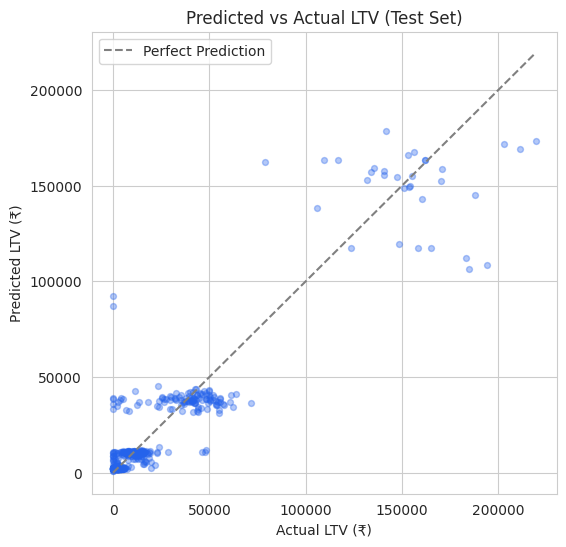

In [9]:
best_model = rf
best_preds = rf_preds

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.35, s=18, color="#2563EB")
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "--", color="gray", label="Perfect Prediction")
plt.xlabel("Actual LTV (₹)")
plt.ylabel("Predicted LTV (₹)")
plt.title("Predicted vs Actual LTV (Test Set)")
plt.legend()
plt.show()

## 7. Feature Importance

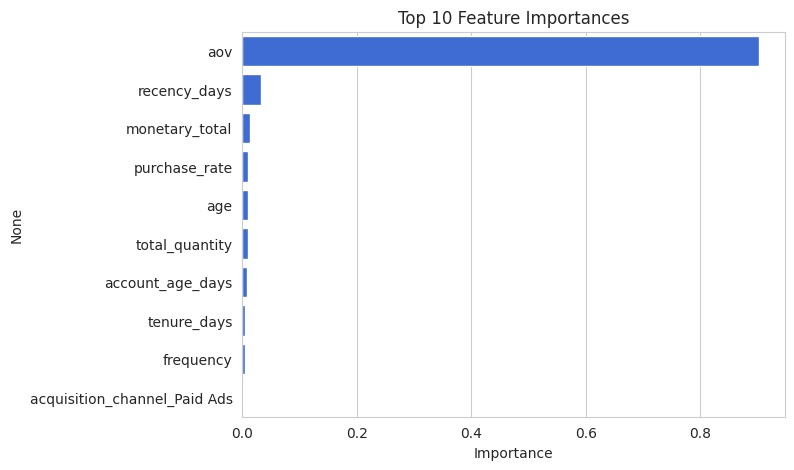

aov                             0.902788
recency_days                    0.032185
monetary_total                  0.012850
purchase_rate                   0.010051
age                             0.009759
total_quantity                  0.009725
account_age_days                0.007867
tenure_days                     0.005591
frequency                       0.004590
acquisition_channel_Paid Ads    0.001323
dtype: float64

In [10]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, color="#2563EB")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()
importances

## 8. Predict for All Customers + Segment

With the model validated, we score the **entire eligible customer base** and bucket them into four actionable segments by predicted LTV quantile: **Low, Medium, High, VIP**.

In [11]:
dataset["predicted_ltv"] = best_model.predict(X).clip(min=0)

q = dataset["predicted_ltv"].quantile([0.4, 0.7, 0.9]).to_dict()

def segment(ltv):
    if ltv >= q[0.9]: return "VIP"
    elif ltv >= q[0.7]: return "High"
    elif ltv >= q[0.4]: return "Medium"
    else: return "Low"

dataset["ltv_segment"] = dataset["predicted_ltv"].apply(segment)
dataset["ltv_segment"].value_counts()

ltv_segment
Low       1200
Medium     900
High       600
VIP        300
Name: count, dtype: int64

In [12]:
seg_summary = dataset.groupby("ltv_segment").agg(
    customers=("customer_id", "count"),
    total_predicted_ltv=("predicted_ltv", "sum")
).reindex(["Low","Medium","High","VIP"])
seg_summary["revenue_share_pct"] = (seg_summary["total_predicted_ltv"] / seg_summary["total_predicted_ltv"].sum() * 100).round(1)
seg_summary

,customers,total_predicted_ltv,revenue_share_pct
ltv_segment,,,
Low,1200,2.710969e+06,4.6
Medium,900,8.792271e+06,14.9
High,600,1.791647e+07,30.4
VIP,300,2.942157e+07,50.0


**Key business insight:** the top-tier (VIP) customers — roughly the top 10% by predicted value — account for around half of total projected revenue. This is the kind of finding that should directly steer retention and loyalty program budget.

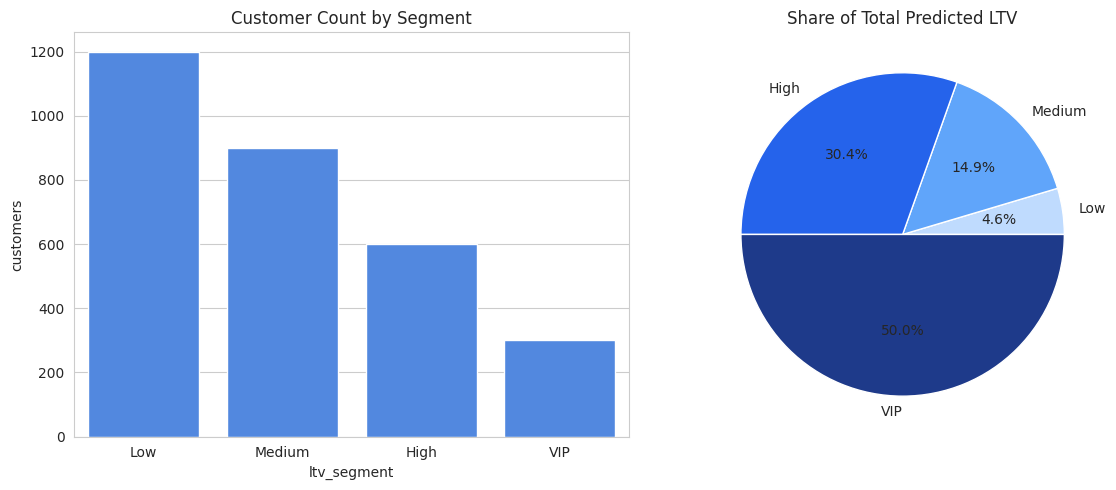

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
order = ["Low","Medium","High","VIP"]
sns.barplot(x=seg_summary.index, y=seg_summary["customers"], order=order, color="#3B82F6", ax=axes[0])
axes[0].set_title("Customer Count by Segment")
axes[1].pie(seg_summary["total_predicted_ltv"], labels=seg_summary.index, autopct="%1.1f%%",
            colors=["#BFDBFE","#60A5FA","#2563EB","#1E3A8A"])
axes[1].set_title("Share of Total Predicted LTV")
plt.tight_layout()
plt.show()

## 9. Save Deliverables

Export the trained model and the final scored customer list for downstream use (e.g., feeding a CRM or marketing automation tool).

In [14]:
joblib.dump(best_model, "../models/ltv_model.pkl")

final_output = dataset[[
    "customer_id", "acquisition_channel", "city_tier", "frequency", "monetary_total",
    "aov", "recency_days", "purchase_rate", "future_ltv", "predicted_ltv", "ltv_segment"
]].sort_values("predicted_ltv", ascending=False)

final_output.to_csv("../outputs/ltv_predictions.csv", index=False)
print(f"Saved {len(final_output):,} scored customers to outputs/ltv_predictions.csv")
final_output.head(10)

Saved 3,000 scored customers to outputs/ltv_predictions.csv


,customer_id,acquisition_channel,city_tier,frequency,monetary_total,aov,recency_days,purchase_rate,future_ltv,predicted_ltv,ltv_segment
1727,CUST01728,Social Media,Tier 2,41.0,138376.98,3375.048293,10.0,4.712644,198317.84,182322.947725,VIP
248,CUST00249,Paid Ads,Tier 2,21.0,69982.82,3332.515238,4.0,3.662791,233225.95,181707.486544,VIP
305,CUST00306,Social Media,Tier 1,42.0,141854.75,3377.494048,1.0,4.532374,201330.79,181184.211700,VIP
1664,CUST01665,Email,Tier 2,23.0,82740.86,3597.428696,5.0,4.035088,222166.00,180612.079678,VIP
1440,CUST01441,Social Media,Tier 1,36.0,118726.40,3297.955556,1.0,4.372470,212888.84,178825.456248,VIP
1088,CUST01089,Referral,Tier 2,42.0,138371.99,3294.571190,0.0,4.436620,190664.06,178809.882432,VIP
532,CUST00533,Organic Search,Tier 1,23.0,85129.44,3701.280000,0.0,3.988439,141864.22,178768.355702,VIP
1616,CUST01617,Social Media,Tier 1,18.0,61751.59,3430.643889,0.0,2.903226,203053.40,178667.163245,VIP
241,CUST00242,Organic Search,Tier 3,23.0,72539.48,3153.890435,12.0,3.965517,212287.12,178650.333779,VIP
446,CUST00447,Social Media,Tier 2,22.0,74760.75,3398.215909,0.0,4.074074,145314.63,177535.190898,VIP


## 10. Conclusions

- **Random Forest outperformed XGBoost** on this dataset (higher R², lower RMSE), likely because the RFM feature set is relatively low-dimensional and Random Forest handles that regime well without heavy tuning.
- **Average order value and recency were the strongest predictors** of future LTV — consistent with classic RFM theory.
- Segmenting customers by predicted LTV surfaces a clear **80/20-style pattern**: a small share of customers drives a disproportionate share of future revenue — exactly the customers a marketing team should prioritize for retention.
- **Next steps for a production version:** incorporate marketing spend/CAC per channel to compute LTV:CAC ratios, add cohort-based validation across multiple time windows, and retrain on a rolling basis as new transaction data arrives.
